# Autoregressive Image Modeling

На основе ноутбука [отсюда](https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/tutorial12/Autoregressive_Image_Modeling.html).

В этом ноутбуке мы реализуем **авторегрессионную модель** для задачи **генерации изображений**.
Авторегрессионные модели представляют собой один из передовых (state-of-the-art) подходов к вероятностному моделированию изображений. Кроме того, они лежат в основе крупных языковых моделей, таких как **GPT-3** и далее.

Аналогично генерации текста, которую вы видели в предыдущих занятиях курса, авторегрессионные модели применяются к изображениям, моделируя **вероятность каждого пикселя при условии всех предыдущих**.
Например, на изображении ниже показано, как мы моделируем пиксель $x_i$ как **условное распределение вероятности** на основе всех предыдущих (здесь выделенных синим) пикселей (автор иллюстрации — [Aaron van den Oord и др.](https://arxiv.org/abs/1601.06759)):

<center width="100%" style="padding: 10px"><img src="https://github.com/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial12/autoregressive_image_modeling.svg?raw=1" width="200px"></center>

В общем случае авторегрессионная модель для многомерных данных $\mathbf{x}$ раскладывает совместное распределение в произведение условных вероятностей:

$$
p(\mathbf{x}) = p(x_1, ..., x_n) = \prod_{i=1}^{n} p(x_i | x_1, ..., x_{i-1})
$$

Обучение таких условных распределений, как правило, значительно проще, чем непосредственное обучение всего совместного распределения $p(\mathbf{x})$.

Однако у авторегрессионных моделей есть и недостатки:

* **Медленная генерация (sampling)** — особенно для больших изображений, поскольку для получения одного изображения нужно выполнить количество проходов вперёд, равное произведению высоты и ширины изображения.
* **Отсутствие скрытого (latent) пространства**, как в VAE (вариационных автокодировщиках) и нормализующих потоках (Normalizing Flows).
  Из-за этого, например, невозможно **интерполировать между двумя изображениями**, так как у модели нет компактного представления в скрытом пространстве.

Мы рассмотрим и обсудим эти преимущества и недостатки в ходе реализации.

---

Наша реализация будет основана на модели **[PixelCNN](https://arxiv.org/pdf/1606.05328.pdf)**.
В настоящее время **PixelCNN** иногда используется в качестве базовой архитектуры, а для улучшения производительности предложены различные модификации (например, [PixelCNN++](https://arxiv.org/pdf/1701.05517.pdf) и [PixelSNAIL](http://proceedings.mlr.press/v80/chen18h/chen18h.pdf)).
Таким образом, реализация PixelCNN — хороший отправной пункт для нас.

---

Прежде всего, нам нужно импортировать стандартные библиотеки. Как и в предыдущих занятиях, мы будем использовать **[PyTorch Lightning](https://pytorch-lightning.readthedocs.io/en/latest/)**.


In [ ]:
## Standard libraries
import os
import math
import numpy as np

## Imports for plotting
import matplotlib.pyplot as plt
plt.set_cmap('cividis')
%matplotlib inline
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('svg', 'pdf') # For export
from matplotlib.colors import to_rgb
import seaborn as sns

## Progress bar
from tqdm.notebook import tqdm

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
# Torchvision
import torchvision
from torchvision.datasets import MNIST
from torchvision import transforms
# PyTorch Lightning
try:
    import pytorch_lightning as pl
except ModuleNotFoundError: # Google Colab does not have PyTorch Lightning installed by default. Hence, we do it here if necessary
    !pip install --quiet pytorch-lightning>=1.4
    import pytorch_lightning as pl
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint

# Path to the folder where the datasets are/should be downloaded (e.g. MNIST)
DATASET_PATH = "../data"
# Path to the folder where the pretrained models are saved
CHECKPOINT_PATH = "../saved_models/ar_models"

# Setting the seed
pl.seed_everything(42)

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Fetching the device that will be used throughout this notebook
device = torch.device("cpu") if not torch.cuda.is_available() else torch.device("cuda:0")
print("Using device", device)

/tmp/ipython-input-1477530374.py:11: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('svg', 'pdf') # For export
INFO:lightning_fabric.utilities.seed:Seed set to 42


Using device cuda:0


<Figure size 640x480 with 0 Axes>

Будем использовать предобученную модель

In [ ]:
import urllib.request
from urllib.error import HTTPError
# Github URL where saved models are stored for this tutorial
base_url = "https://raw.githubusercontent.com/phlippe/saved_models/main/tutorial12/"
# Files to download
pretrained_files = ["PixelCNN.ckpt"]
# Create checkpoint path if it doesn't exist yet
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

# For each file, check whether it already exists. If not, try downloading it.
for file_name in pretrained_files:
    file_path = os.path.join(CHECKPOINT_PATH, file_name)
    if not os.path.isfile(file_path):
        file_url = base_url + file_name
        print(f"Downloading {file_url}...")
        try:
            urllib.request.urlretrieve(file_url, file_path)
        except HTTPError as e:
            print("Something went wrong. Please try to download the file from the GDrive folder, or contact the author with the full output including the following error:\n", e)

Будем работать с датасетом MNIST

In [ ]:
# Convert images from 0-1 to 0-255 (integers). We use the long datatype as we will use the images as labels as well
def discretize(sample):
    return (sample * 255).to(torch.long)

# Transformations applied on each image => only make them a tensor
transform = transforms.Compose([transforms.ToTensor(),
                                discretize])

# Loading the training dataset. We need to split it into a training and validation part
train_dataset = MNIST(root=DATASET_PATH, train=True, transform=transform, download=True)
pl.seed_everything(42)
train_set, val_set = torch.utils.data.random_split(train_dataset, [50000, 10000])

# Loading the test set
test_set = MNIST(root=DATASET_PATH, train=False, transform=transform, download=True)

# We define a set of data loaders that we can use for various purposes later.
train_loader = data.DataLoader(train_set, batch_size=128, shuffle=True, drop_last=True, pin_memory=True, num_workers=4)
val_loader = data.DataLoader(val_set, batch_size=128, shuffle=False, drop_last=False, num_workers=4)
test_loader = data.DataLoader(test_set, batch_size=128, shuffle=False, drop_last=False, num_workers=4)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 480kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.72MB/s]
INFO:lightning_fabric.utilities.seed:Seed set to 42
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Вспомним как выглядят данные :)

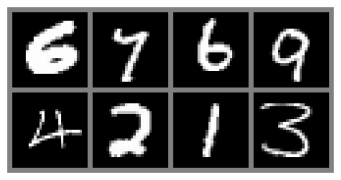

In [ ]:
def show_imgs(imgs):
    num_imgs = imgs.shape[0] if isinstance(imgs, torch.Tensor) else len(imgs)
    nrow = min(num_imgs, 4)
    ncol = int(math.ceil(num_imgs/nrow))
    imgs = torchvision.utils.make_grid(imgs, nrow=nrow, pad_value=128)
    imgs = imgs.clamp(min=0, max=255)
    np_imgs = imgs.cpu().numpy()
    plt.figure(figsize=(1.5*nrow, 1.5*ncol))
    plt.imshow(np.transpose(np_imgs, (1,2,0)), interpolation='nearest')
    plt.axis('off')
    plt.show()
    plt.close()

show_imgs([train_set[i][0] for i in range(8)])

## Маскированные авторегрессионные свёртки

Основным строительным блоком **PixelCNN** являются **маскированные свёртки (masked convolutions)**.
В отличие от языковых моделей, где мы применяем LSTM к каждому элементу (например, слову) по одному, в случае изображений это было бы крайне неэффективно, потому что изображения — это **двумерные сетки**, а не последовательности.
Поэтому здесь логичнее использовать **свёрточные операции (convolutions)**, которые отлично зарекомендовали себя в глубоких сверточных нейросетях (CNN), применяемых для классификации изображений.

---

Однако мы **не можем просто использовать обычные свёртки без изменений**.

Чтобы гарантировать, что **предсказание конкретного пикселя зависит только от предыдущих пикселей**, а **не от его собственного значения или “будущих” пикселей**.
Чтобы это обеспечить, мы применяем **свёртки с маской (masked convolutions)**.

---

Тип маски зависит от того, **в каком порядке мы обходим пиксели**, то есть:

* какой пиксель мы считаем первым,
* какой — вторым и т.д.

Наиболее распространённый порядок — **построчный (row-wise)**:
первым считается **верхний левый пиксель**, затем — пиксель справа от него, и так далее, пока не закончится строка; после этого переходим к следующей строке, начиная снова с первого столбца.

---

Чтобы реализовать это в свёртках, нам нужно убедиться, что:

* предсказание первого пикселя **не зависит от его собственного “истинного” значения**;
* оно **не зависит от пикселей, находящихся справа** от него в той же строке;
* и **не зависит от пикселей, находящихся ниже**.

В терминах свёрточного фильтра это означает, что **некоторые элементы весовой матрицы должны быть обнулены**, чтобы фильтр «не видел» запрещённые (будущие) пиксели.

Пример такой маски для **ядра 5×5** показан ниже
(автор иллюстрации — [Aaron van den Oord](https://arxiv.org/pdf/1606.05328.pdf)):

<center width="100%" style="padding: 10px"><img src="https://github.com/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial12/masked_convolution.svg?raw=1" width="150px"></center>

---

Прежде чем рассматривать применение маскированных свёрток в **PixelCNN** более подробно, давайте сначала реализуем модуль, который позволит применять **произвольную маску** к свёртке.


In [ ]:
class MaskedConvolution(nn.Module):

    def __init__(self, c_in, c_out, mask, **kwargs):
        """
        Implements a convolution with mask applied on its weights.
        Inputs:
            c_in - Number of input channels
            c_out - Number of output channels
            mask - Tensor of shape [kernel_size_H, kernel_size_W] with 0s where
                   the convolution should be masked, and 1s otherwise.
            kwargs - Additional arguments for the convolution
        """
        super().__init__()
        # For simplicity: calculate padding automatically
        kernel_size = (mask.shape[0], mask.shape[1])
        dilation = 1 if "dilation" not in kwargs else kwargs["dilation"]
        padding = tuple([dilation*(kernel_size[i]-1)//2 for i in range(2)])
        # Actual convolution
        self.conv = nn.Conv2d(c_in, c_out, kernel_size, padding=padding, **kwargs)

        # Mask as buffer => it is no parameter but still a tensor of the module
        # (must be moved with the devices)
        self.register_buffer('mask', mask[None,None])

    def forward(self, x):
        self.conv.weight.data *= self.mask # Ensures zero's at masked positions
        return self.conv(x)

### Вертикальные и горизонтальные стеки свёрток

Чтобы построить собственную **авторегрессионную модель для изображений**, можно просто **последовательно наложить несколько маскированных свёрток** одну на другую.

Именно так было реализовано в **оригинальной модели PixelCNN**, описанной в статье [*Pixel Recurrent Neural Networks*](https://arxiv.org/pdf/1601.06759.pdf).
Однако у такого подхода есть **существенная проблема**.

При последовательном применении нескольких маскированных свёрток у каждого пикселя формируется **“слепая зона” (blind spot)** — область, в которую модель не может «заглянуть».
Эта слепая зона находится **в правом верхнем углу** относительно текущего пикселя (см. рисунок ниже, источник — [Aaron van den Oord и др.](https://arxiv.org/pdf/1606.05328.pdf)):

<center width="100%" style="padding: 10px"><img src="https://github.com/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial12/pixelcnn_blind_spot.svg?raw=1" width="275px"></center>

Хотя пиксель, по идее, должен учитывать **все пиксели, расположенные выше и левее него**, стек из маскированных свёрток **не позволяет “видеть” пиксели, находящиеся сверху, но правее**.

Причина в том, что признаки (features) пикселей, расположенных выше, которые используются в последующей свёртке, **не содержат информации о пикселях, находящихся справа в той же строке**.
Если бы они её содержали — это означало бы, что модель «подглядывает в будущее» (что нарушает авторегрессионное предположение).

Чтобы решить эту проблему, **van den Oord и соавторы предложили разделить свёртки на два типа:**

* **вертикальный стек (vertical stack)** — обрабатывает все пиксели, расположенные **выше** текущего;
* **горизонтальный стек (horizontal stack)** — обрабатывает пиксели, находящиеся **слева** от текущего.

При этом, **разделив** эти два направления, можно передавать информацию о пикселях, находящихся **справа**, через вертикальный стек, **не нарушая авторегрессионного ограничения**.

На рисунке выше также показано, как именно выглядят эти две свёртки.

---

Теперь реализуем эти две свёртки — **вертикальную и горизонтальную** — следующим образом:


In [ ]:
class VerticalStackConvolution(MaskedConvolution):

    def __init__(self, c_in, c_out, kernel_size=3, mask_center=False, **kwargs):
       # Создаётся квадратная матрица из единиц (kernel_size × kernel_size), которая будет маской.
       # Все элементы ниже центральной строки зануляются (=0) → это значит, что фильтр не может смотреть вниз
       # (т.е. на пиксели ниже текущего).
        mask = torch.ones(kernel_size, kernel_size)
        mask[kernel_size//2+1:,:] = 0

       # Если mask_center=True, то обнуляется центральная строка, то есть пиксель не видит даже себя самого.
       # Это используется при самой первой свёртке, чтобы не допустить “подглядывания” текущего значения.
        if mask_center:
            mask[kernel_size//2,:] = 0

        super().__init__(c_in, c_out, mask, **kwargs)

class HorizontalStackConvolution(MaskedConvolution):

    def __init__(self, c_in, c_out, kernel_size=3, mask_center=False, **kwargs):
        mask = torch.ones(1,kernel_size)
        mask[0,kernel_size//2+1:] = 0

        if mask_center:
            mask[0,kernel_size//2] = 0

        super().__init__(c_in, c_out, mask, **kwargs)

Обратите внимание, что у нас есть входной аргумент под названием `mask_center`.
**Входом модели является само исходное изображение**.
Поэтому **самая первая свёртка**, которую мы применяем, **не может использовать центральный пиксель** в качестве входных данных — его нужно **маскировать**.

Однако **все последующие свёртки** уже **должны использовать центральный пиксель**, иначе мы потеряем информацию (признаки), полученные на предыдущем слое.

Таким образом, аргумент `mask_center` принимает значение **True** только для **первых свёрток**, и **False** — для всех последующих.

### Визуализация рецептивного поля

Чтобы проверить корректность нашей реализации **маскированных свёрток**, мы можем **визуализировать поле восприятия (receptive field)**, получаемое при их использовании.

Мы должны увидеть, что при увеличении числа свёрточных слоёв **поле восприятия расширяется** — как по вертикали, так и по горизонтали — и при этом **пропадает проблема «слепой зоны» (blind spot)**.

Поле восприятия можно **эмпирически измерить**, если выполнить **обратное распространение (backpropagation)** некоторой произвольной функции потерь по отношению к **входному изображению** для конкретного пикселя на выходе.

Эту идею мы реализуем ниже и визуализируем полученное рецептивное поле.


Что делаем ниже:

- Создаём изображение, заполненное нулями
- Пропускаем его через модель (или просто используем как out = inp_img для теста)
- Берём градиент выхода по входу
- Смотрим, какие пиксели входа получили ненулевой градиент → именно они входят в рецептивное поле.

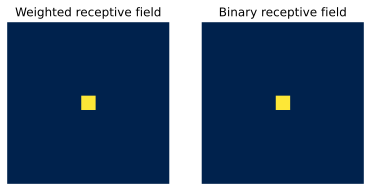

In [ ]:
inp_img = torch.zeros(1, 1, 11, 11)
inp_img.requires_grad_()

def show_center_recep_field(img, out):
    """
    Calculates the gradients of the input with respect to the output center pixel,
    and visualizes the overall receptive field.
    Inputs:
        img - Input image for which we want to calculate the receptive field on.
        out - Output features/loss which is used for backpropagation, and should be
              the output of the network/computation graph.
    """

    # Берём центральный пиксель выходного изображения out (по центру: img.shape[2]//2, img.shape[3]//2)
    # Складываем все каналы (если их несколько)
    # Ниже — «фиктивная» функция потерь, просто чтобы можно было вызвать backward()

    loss = out[0,:,img.shape[2]//2,img.shape[3]//2].sum()
    loss.backward(retain_graph=True) # Retain graph as we want to stack multiple layers and show the receptive field of all of them
    img_grads = img.grad.abs()
    img.grad.fill_(0) # Reset grads

    # Plot receptive field
    img = img_grads.squeeze().cpu().numpy()
    fig, ax = plt.subplots(1,2)
    pos = ax[0].imshow(img)
    ax[1].imshow(img>0)
    # Mark the center pixel in red if it doesn't have any gradients (should be the case for standard autoregressive models)
    show_center = (img[img.shape[0]//2,img.shape[1]//2] == 0)
    if show_center:
        center_pixel = np.zeros(img.shape + (4,))
        center_pixel[center_pixel.shape[0]//2,center_pixel.shape[1]//2,:] = np.array([1.0, 0.0, 0.0, 1.0])
    for i in range(2):
        ax[i].axis('off')
        if show_center:
            ax[i].imshow(center_pixel)
    ax[0].set_title("Weighted receptive field")
    ax[1].set_title("Binary receptive field")
    plt.show()
    plt.close()

show_center_recep_field(inp_img, inp_img)

Мы видим, что вызвали исходное изображение без сверток - то есть только сам центральный пиксель влияет на себя.

Давайте сначала **визуализируем поле восприятия горизонтальной свёртки**, в которой **центральный пиксель исключён** (маскирован).

Мы возьмём небольшое произвольное входное изображение размером **11×11 пикселей** и вычислим **функцию потерь для центрального пикселя**.

Для упрощения и наглядности инициализируем **все веса единицами**, **смещение (bias)** — **нулём**, и используем **только один канал**.
Этого достаточно для целей визуализации.

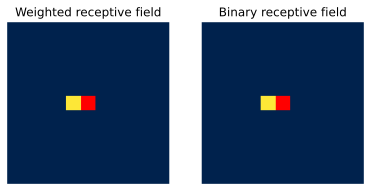

In [ ]:
horiz_conv = HorizontalStackConvolution(c_in=1, c_out=1, kernel_size=3, mask_center=True)
horiz_conv.conv.weight.data.fill_(1)
horiz_conv.conv.bias.data.fill_(0)
horiz_img = horiz_conv(inp_img)
show_center_recep_field(inp_img, horiz_img)

Поле восприятия показано **жёлтым**, центральный пиксель — **красным**, а все остальные пиксели, которые **не входят в поле восприятия**, — **тёмно-синие**.

Как и ожидалось, у **одной горизонтальной свёртки** с **маскированным центральным пикселем** и ядром **3×3** поле восприятия включает **только пиксель слева**.
Если использовать **большее ядро**, в расчёт будут приниматься **несколько пикселей слева**.

Далее давайте посмотрим на **вертикальную свёртку**:


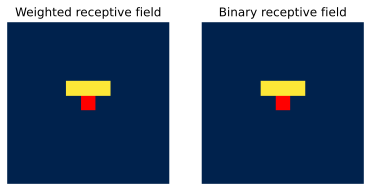

In [ ]:
vert_conv = VerticalStackConvolution(c_in=1, c_out=1, kernel_size=3, mask_center=True)
vert_conv.conv.weight.data.fill_(1)
vert_conv.conv.bias.data.fill_(0)
vert_img = vert_conv(inp_img)
show_center_recep_field(inp_img, vert_img)

Вертикальная свёртка учитывает **все пиксели, расположенные выше**.

Если объединить её с горизонтальной свёрткой, мы получаем **поле восприятия**, характерное для **оригинальной маскированной свёртки**.

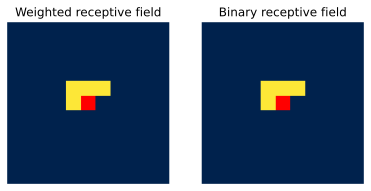

In [ ]:
horiz_img = vert_img + horiz_img
show_center_recep_field(inp_img, horiz_img)

Если мы **используем стек из нескольких горизонтальных и вертикальных свёрток**, нужно учитывать два важных момента:

---

### 1️⃣ Центр больше не должен быть маскирован

* В **последующих свёртках** центральный пиксель уже **не нужно исключать**, потому что признаки на его позиции теперь **не зависят от исходного значения пикселя**.

---

### 2️⃣ Вертикальная свёртка **не должна использовать признаки горизонтальной свёртки**

* В **горизонтальной свёртке** каждый пиксель уже содержит информацию обо всех **“истинных” пикселях слева**.
* Если вертикальная свёртка возьмёт эти признаки, она **получит доступ к “будущим” пикселям**, чего мы хотим избежать.
* Поэтому **вертикальная свёртка работает только со своими предыдущими признаками**, а объединение потоков признаков разрешается **только для горизонтального стека**.

---

### 🔄 Как использовать стеки из свёрток

1. Есть **два потока признаков**:

   * **Vertical stack** (вертикальный поток)
   * **Horizontal stack** (горизонтальный поток)
2. Горизонтальные свёртки могут использовать **объединённые признаки** предыдущих горизонтальных и вертикальных слоёв.
3. Вертикальный стек **использует только свои предыдущие признаки**.
4. На каждом слое можно **суммировать выходы горизонтального и вертикального потоков** и использовать их для вычисления функции потерь.

---

### 📌 Итог

Такой подход позволяет:

* Расширять поле восприятия постепенно,
* При этом **не допускать утечки информации из будущего** (правило авторегрессии).

В реализации показан пример с **4 последовательными слоями**, где признаки горизонтальных и вертикальных свёрток суммируются на каждом слое.


Layer 2


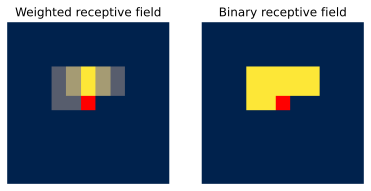

Layer 3


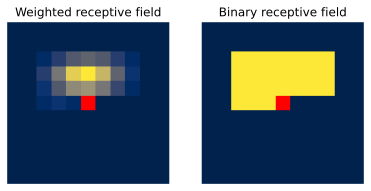

Layer 4


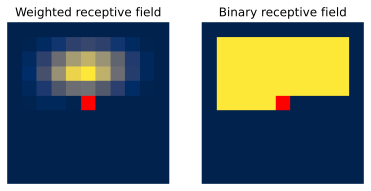

Layer 5


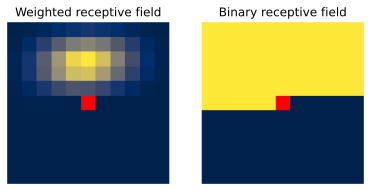

In [ ]:
# Initialize convolutions with equal weight to all input pixels
horiz_conv = HorizontalStackConvolution(c_in=1, c_out=1, kernel_size=3, mask_center=False)
horiz_conv.conv.weight.data.fill_(1)
horiz_conv.conv.bias.data.fill_(0)
vert_conv = VerticalStackConvolution(c_in=1, c_out=1, kernel_size=3,mask_center=False)
vert_conv.conv.weight.data.fill_(1)
vert_conv.conv.bias.data.fill_(0)

# We reuse our convolutions for the 4 layers here. Note that in a standard network,
# we don't do that, and instead learn 4 separate convolution. As this cell is only for
# visualization purposes, we reuse the convolutions for all layers.
for l_idx in range(4):
    vert_img = vert_conv(vert_img)
    horiz_img = horiz_conv(horiz_img) + vert_img
    print(f"Layer {l_idx+2}")
    show_center_recep_field(inp_img, horiz_img)

Поле восприятие выше показано для **горизонтального стека**, который **включает признаки вертикальных свёрток**.
Оно **растёт с увеличением числа слоёв** без каких-либо «слепых зон», как это было раньше.

Разница между **“weighted”** и **“binary”** полями восприятия в следующем:

* Для **binary** проверяется, **текут ли какие-либо градиенты к этому пикселю**.
  Это показывает, что **центральный пиксель действительно может использовать информацию с этого пикселя**.
* Для **weighted** учитывается **сила влияния пикселя**, поскольку из-за весов свёртки некоторые пиксели **сильнее влияют на предсказание**, чем другие.
  Это визуализируется путём отображения **модуля градиента каждого пикселя**, а не просто бинарного да/нет.

Ещё одно поле восприятия, которое мы можем проверить, — это **вертикальный стек**, так как выше мы рассматривали горизонтальный стек. Давайте визуализируем его ниже:


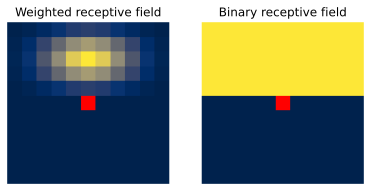

In [ ]:
show_center_recep_field(inp_img, vert_img)

Как мы обсуждали ранее, **вертикальный стек смотрит только на пиксели, расположенные выше того, который мы хотим предсказать**.
Таким образом, мы можем убедиться, что наша реализация **работает так, как мы изначально ожидали**.

В качестве заключительного шага давайте **очистим вычислительный граф**, который мы оставили в памяти для визуализации рецептивного поля:

In [ ]:
del inp_img, horiz_conv, vert_conv

## Gated PixelCNN

На следующем этапе мы будем использовать **маскированные свёртки**, чтобы построить полноценную авторегрессионную модель, называемую **Gated PixelCNN**.

Разница между **оригинальным PixelCNN** и **Gated PixelCNN** заключается в использовании **отдельных горизонтального и вертикального стеков**.
Однако в литературе часто говорят просто “PixelCNN”, подразумевая **gated-версию**.
То, что в названии модели есть слово **“Gated”**, объясняется ниже.

---

### Gated Convolutions

Для визуализации поля восприятия мы использовали очень упрощённый стек вертикальных и горизонтальных свёрток.
На практике PixelCNN применяет **gated-свёртки**, которые позволяют моделировать более сложные взаимодействия между пикселями.

### Зачем это нужно:
- Обычная PixelCNN одинаково учитывает все предыдущие пиксели
- Нам нужен механизм, который может усиливать влияние некоторых пикселей и уменьшать влияние других - это как раз gated-механизм:

$$выход=tanh(сигнал)\cdot σ(гейт)$$

**Gated Convolution блок** в PixelCNN выглядит следующим образом:

<center width="100%"><img src="https://github.com/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial12/PixelCNN_GatedConv.svg?raw=1" width="700px" style="padding: 15px"/></center>

* **Левый путь** — вертикальный стек (маскированная N×N свёртка)
* **Правый путь** — горизонтальный стек

Гейтовые свёртки реализуются с помощью **двойного по размеру выходного канала** и объединяются **поэлементным умножением** функций `tanh` и `sigmoid`.
Для линейного слоя это можно записать как:

$$
\mathbf{y} = \tanh\left(\mathbf{W}*{f}\mathbf{x}\right) \odot \sigma\left(\mathbf{W}*{g}\mathbf{x}\right)
$$

* Здесь **смещения (bias)** опущены, а линейный слой разделён на две части: $\mathbf{W}_f$ и $\mathbf{W}_g$.
* Концепция напоминает **входной и модулирующий гейт LSTM** и использовалась во многих других архитектурах.
* Основная цель гейтовых активаций — **моделировать более сложные взаимодействия** и **облегчить обучение**, но это в основном **дизайнерский выбор** и может рассматриваться как **гиперпараметр**.

---

Дополнительно:

* **Горизонтальный стек** использует **residual connection** (остаточное соединение), а вертикальный — нет.
* Это связано с тем, что **выход горизонтального стека используется для предсказания пикселя**.
* Вертикальный стек получает сильный сигнал градиента через всего **две 1×1 свёртки до residual**, поэтому ему не требуется отдельное остаточное соединение для всех предыдущих слоёв.

---

Реализовать такой блок в PyTorch достаточно просто, потому что **визуализация выше даёт понятный вычислительный граф**, по которому можно строить модель.

In [ ]:
class GatedMaskedConv(nn.Module):

    def __init__(self, c_in, **kwargs):
        """
        Gated Convolution block implemented the computation graph shown above.
        """
        super().__init__()
        self.conv_vert = VerticalStackConvolution(c_in, c_out=2*c_in, **kwargs)
        self.conv_horiz = HorizontalStackConvolution(c_in, c_out=2*c_in, **kwargs)
        self.conv_vert_to_horiz = nn.Conv2d(2*c_in, 2*c_in, kernel_size=1, padding=0)
        self.conv_horiz_1x1 = nn.Conv2d(c_in, c_in, kernel_size=1, padding=0)

    def forward(self, v_stack, h_stack):
        # Vertical stack (left)
        v_stack_feat = self.conv_vert(v_stack)
        v_val, v_gate = v_stack_feat.chunk(2, dim=1)
        v_stack_out = torch.tanh(v_val) * torch.sigmoid(v_gate)

        # Horizontal stack (right)
        h_stack_feat = self.conv_horiz(h_stack)
        h_stack_feat = h_stack_feat + self.conv_vert_to_horiz(v_stack_feat)
        h_val, h_gate = h_stack_feat.chunk(2, dim=1)
        h_stack_feat = torch.tanh(h_val) * torch.sigmoid(h_gate)
        h_stack_out = self.conv_horiz_1x1(h_stack_feat)
        h_stack_out = h_stack_out + h_stack

        return v_stack_out, h_stack_out

### Построение модели

Используя **гейтовые свёртки**, мы теперь можем построить нашу модель **PixelCNN**.

Архитектура состоит из **нескольких подряд идущих блоков GatedMaskedConv**, при этом к некоторым свёрткам добавляется **фактор дилатации (dilation)**.

* Это позволяет **увеличить поле восприятия модели** и учитывать **более широкий контекст** при генерации изображений.

Напомним, как работает **дилатация свёртки** (figure credit — [Vincent Dumoulin и Francesco Visin](https://arxiv.org/pdf/1603.07285.pdf)):

<center width="100%"><img src="https://raw.githubusercontent.com/vdumoulin/conv_arithmetic/master/gif/dilation.gif" width="250px"></center>

> Заметим, что уменьшение размера выхода на визуализации связано с отсутствием паддинга. В нашей реализации мы **добавим паддинг** к входному изображению.

---

Ниже мы реализуем модель **PixelCNN** как модуль **PyTorch Lightning**:

* Помимо стека гейтовых свёрток, у нас есть **начальные горизонтальная и вертикальная свёртки**, которые маскируют центральный пиксель.
* В конце используется **1×1 свёртка**, которая преобразует выходные признаки в предсказания классов.

Для вычисления **вероятности (likelihood)** батча изображений:

1. Создаём **начальные признаки** с помощью маскированных горизонтальной и вертикальной свёртки на входе.
2. Пропускаем признаки через **стек гейтовых свёрток**.
3. Берём **выходные признаки горизонтального стека** и применяем **1×1 свёртку** для классификации.

Для метрики likelihood используется **bits per dimension**.


In [ ]:
class PixelCNN(pl.LightningModule):

    def __init__(self, c_in, c_hidden):
        super().__init__()
        self.save_hyperparameters()

        # Initial convolutions skipping the center pixel
        self.conv_vstack = VerticalStackConvolution(c_in, c_hidden, mask_center=True)
        self.conv_hstack = HorizontalStackConvolution(c_in, c_hidden, mask_center=True)
        # Convolution block of PixelCNN. We use dilation instead of downscaling
        self.conv_layers = nn.ModuleList([
            GatedMaskedConv(c_hidden),
            GatedMaskedConv(c_hidden, dilation=2),
            GatedMaskedConv(c_hidden),
            GatedMaskedConv(c_hidden, dilation=4),
            GatedMaskedConv(c_hidden),
            GatedMaskedConv(c_hidden, dilation=2),
            GatedMaskedConv(c_hidden)
        ])
        # Output classification convolution (1x1)
        self.conv_out = nn.Conv2d(c_hidden, c_in * 256, kernel_size=1, padding=0)

        self.example_input_array = train_set[0][0][None]

    def forward(self, x):
        """
        Forward image through model and return logits for each pixel.
        Inputs:
            x - Image tensor with integer values between 0 and 255.
        """
        # Scale input from 0 to 255 back to -1 to 1
        x = (x.float() / 255.0) * 2 - 1

        # Initial convolutions
        v_stack = self.conv_vstack(x)
        h_stack = self.conv_hstack(x)
        # Gated Convolutions
        for layer in self.conv_layers:
            v_stack, h_stack = layer(v_stack, h_stack)
        # 1x1 classification convolution
        # Apply ELU before 1x1 convolution for non-linearity on residual connection
        out = self.conv_out(F.elu(h_stack))

        # Output dimensions: [Batch, Classes, Channels, Height, Width]
        out = out.reshape(out.shape[0], 256, out.shape[1]//256, out.shape[2], out.shape[3])
        return out

    def calc_likelihood(self, x):
        # Forward pass with bpd likelihood calculation
        pred = self.forward(x)
        nll = F.cross_entropy(pred, x, reduction='none')
        bpd = nll.mean(dim=[1,2,3]) * np.log2(np.exp(1))
        return bpd.mean()

    @torch.no_grad()
    def sample(self, img_shape, img=None):
        """
        Sampling function for the autoregressive model.
        Inputs:
            img_shape - Shape of the image to generate (B,C,H,W)
            img (optional) - If given, this tensor will be used as
                             a starting image. The pixels to fill
                             should be -1 in the input tensor.
        """
        # Create empty image
        if img is None:
            img = torch.zeros(img_shape, dtype=torch.long).to(device) - 1
        # Generation loop
        for h in tqdm(range(img_shape[2]), leave=False):
            for w in range(img_shape[3]):
                for c in range(img_shape[1]):
                    # Skip if not to be filled (-1)
                    if (img[:,c,h,w] != -1).all().item():
                        continue
                    # For efficiency, we only have to input the upper part of the image
                    # as all other parts will be skipped by the masked convolutions anyways
                    pred = self.forward(img[:,:,:h+1,:])
                    probs = F.softmax(pred[:,:,c,h,w], dim=-1)
                    img[:,c,h,w] = torch.multinomial(probs, num_samples=1).squeeze(dim=-1)
        return img

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=1e-3)
        scheduler = optim.lr_scheduler.StepLR(optimizer, 1, gamma=0.99)
        return [optimizer], [scheduler]

    def training_step(self, batch, batch_idx):
        loss = self.calc_likelihood(batch[0])
        self.log('train_bpd', loss)
        return loss

    def validation_step(self, batch, batch_idx):
        loss = self.calc_likelihood(batch[0])
        self.log('val_bpd', loss)

    def test_step(self, batch, batch_idx):
        loss = self.calc_likelihood(batch[0])
        self.log('test_bpd', loss)

Чтобы **сгенерировать изображение из авторегрессионной модели**, нужно **итерироваться по всем пикселям входа**.

1. **Начинаем с пустого изображения** и заполняем пиксели **по одному**, начиная с **верхнего левого угла**.
2. При предсказании (x_i) **все пиксели ниже него не влияют на предсказание**.

   * Это значит, что можно **сократить высоту изображения** для вычислений без потери точности, повышая эффективность.
3. Однако, все **циклы в функции сэмплинга** показывают, что процесс **достаточно медленный**:

   * Можно было бы **повторно использовать вычисления**, так как признаки уже предсказанных пикселей не меняются,
   * Но это требует значительных усилий для реализации, поэтому чаще всего **оставляют последовательный подход**.
   * В итоге **авторегрессионный сэмплинг остаётся последовательным и медленным**.

Перед обучением модели мы можем **проверить полное рецептивное поле модели** на изображении MNIST размером (28 \times 28):

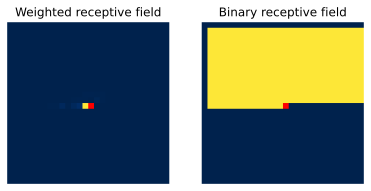

In [ ]:
test_model = PixelCNN(c_in=1, c_hidden=64)
inp = torch.zeros(1,1,28,28)
inp.requires_grad_()
out = test_model(inp)
show_center_recep_field(inp, out.squeeze(dim=2))
del inp, out, test_model

Визуализация показывает, что **для предсказания любого пикселя мы можем учитывать только половину изображения**.
Однако стоит помнить, что это — **«теоретическое» рецептивное поле**, а не обязательно **эффективное рецептивное поле**, которое обычно гораздо меньше.

### Цикл обучения

Для обучения модели мы снова можем использовать **PyTorch Lightning** и написать функцию для **загрузки предварительно обученной модели**, если она уже существует.

Чтобы **снизить вычислительные затраты**, мы **уже сохранили значения метрик на валидации и тесте** в чекпойнте.

In [ ]:
def train_model(**kwargs):
    # Create a PyTorch Lightning trainer with the generation callback
    trainer = pl.Trainer(default_root_dir=os.path.join(CHECKPOINT_PATH, "PixelCNN"),
                         accelerator="gpu" if str(device).startswith("cuda") else "cpu",
                         devices=1,
                         max_epochs=150,
                         callbacks=[ModelCheckpoint(save_weights_only=True, mode="min", monitor="val_bpd"),
                                    LearningRateMonitor("epoch")])
    result = None
    # Check whether pretrained model exists. If yes, load it and skip training
    pretrained_filename = os.path.join(CHECKPOINT_PATH, "PixelCNN.ckpt")
#    pretrained_filename = ""
    if os.path.isfile(pretrained_filename):
        print("Found pretrained model, loading...")
        model = PixelCNN.load_from_checkpoint(pretrained_filename)
        ckpt = torch.load(pretrained_filename, map_location=device)
        result = ckpt.get("result", None)
    else:
        model = PixelCNN(**kwargs)
        trainer.fit(model, train_loader, val_loader)
    model = model.to(device)

    if result is None:
        # Test best model on validation and test set
        val_result = trainer.test(model, val_loader, verbose=False)
        test_result = trainer.test(model, test_loader, verbose=False)
        result = {"test": test_result, "val": val_result}
    return model, result

Обучение модели занимает много времени, поэтому мы рекомендуем использовать **предварительно обученную модель**, чтобы пройти весь ноутбук.
Однако вы можете **поэкспериментировать с гиперпараметрами**, например с числом слоёв, чтобы получить представление о их влиянии.

При вызове функции обучения с **предварительно обученной моделью** она **автоматически загружается**, и сразу выводится её **результат на тестовом наборе**.

In [ ]:
model, result = train_model(c_in=1, c_hidden=64)
test_res = result["test"][0]
print("Test bits per dimension: %4.3fbpd" % (test_res["test_loss"] if "test_loss" in test_res else test_res["test_bpd"]))

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Found pretrained model, loading...


INFO:pytorch_lightning.utilities.migration.utils:Lightning automatically upgraded your loaded checkpoint from v0.9.0 to v2.5.6. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint ../saved_models/ar_models/PixelCNN.ckpt`


Test bits per dimension: 0.808bpd


# Метрика BPD или “сколько бит нужно на один пиксель”

BPD (bits per dimension/pixel) измеряет среднее количество бит, необходимых для кодирования каждого пикселя изображения. Для изображения размером $H \times W$ с $C$ каналами формула выглядит так:

$$
\text{BPD} = \frac{1}{H \cdot W \cdot C} \sum_{c=1}^{C} \sum_{h=1}^{H} \sum_{w=1}^{W} -\log_2 p(x_{c,h,w})
$$

где $p(x_{c,h,w})$ — вероятность модели для истинного значения пикселя $(c,h,w)$.

Пусть есть случайная величина $x$ (например, значение пикселя) с вероятностью $p(x)$, минимальное количество бит, необходимое для кодирования без потерь, описывает формула Шеннона:

$$
\text{bits} = -\log_2 p(x)
$$

- Если событие вероятное (модель с большой вероятностью предсказывает верный класс) → $-\log_2 p(x)$ маленькое (мало бит нужно).  
- Если событие редкое → нужно много бит.  

Когда модель предсказывает $p(x)$:

- Она учится давать высокую вероятность правильным пикселям,  
- И низкую вероятность — неправильным,  
- Что прямо пропорционально количеству бит для кодирования.  

Меньше бит → модель увереннее и точнее предсказывает пиксели.


Ошибка на тесте **0.809 bpd** - это хороший результат.

Давайте также **измерим количество параметров** в PixelCNN:

In [ ]:
num_params = sum([np.prod(param.shape) for param in model.parameters()])
print("Number of parameters: {:,}".format(num_params))

Number of parameters: 852,160


Это небольшое число параметров для такой задачи :)

## Sampling

Визуализируем результаты генерации:

INFO:lightning_fabric.utilities.seed:Seed set to 1


  0%|          | 0/28 [00:00<?, ?it/s]

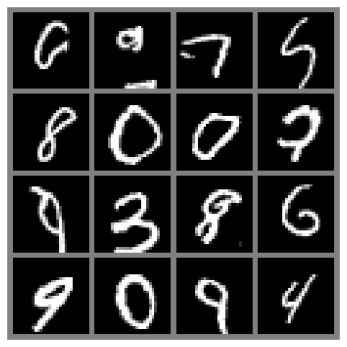

In [ ]:
pl.seed_everything(1)
samples = model.sample(img_shape=(16,1,28,28))
show_imgs(samples.cpu())

Большинство сгенерированных картинок **можно распознать как цифры**.

Однако видно, что модели **есть куда расти**, так как значительное количество картинок всё ещё трудно распознать (например, первая строка).
**Более глубокие авторегрессионные модели** должны давать **лучшее качество**, так как могут учитывать **больше контекста при генерации пикселей**.

Сама обученная модель **не ограничена конкретным размером изображения**.
Но что произойдёт, если мы попробуем **сгенерировать изображение большее**, чем видели на этапе обучения?
Давайте попробуем **сэмплировать изображения размером 64×64 вместо 28×28**:


INFO:lightning_fabric.utilities.seed:Seed set to 1


  0%|          | 0/64 [00:00<?, ?it/s]

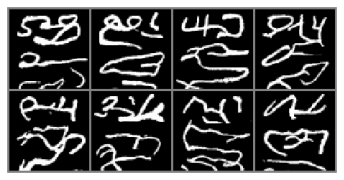

In [ ]:
pl.seed_everything(1)
samples = model.sample(img_shape=(8,1,64,64))
show_imgs(samples.cpu())

Более крупные изображения показывают, что **изменение размера изображения во время тестирования сбивает модель**, и она генерирует **абстрактные фигуры** (иногда можно разглядеть цифру в верхнем левом углу).

Кроме того, **сэмплирование изображений размером 64×64 пикселя** занимает **более минуты на GPU**.

Очевидно, что **авторегрессионные модели не масштабируются на большие изображения** без изменения процедуры сэмплинга, например, используя подходы вроде **forecasting**.

Наша реализация также **не самая эффективная**, так как **многие вычисления можно сохранить и переиспользовать** в процессе сэмплинга.

### Автодополнение (Autocompletion)

Обычное применение авторегрессионных моделей — **автодополнение изображения**.

* Так как авторегрессионные модели **предсказывают пиксели по одному**, мы можем **задать первые (N) пикселей** заранее и посмотреть, **как модель дополнит оставшуюся часть изображения**.
* Для реализации этого **в цикле сэмплинга пропускаются итерации** для пикселей, которые уже имеют значение, отличное от -1.

  * В нашем **PyTorch Lightning модуле** выше есть конкретная реализация этого подхода.

---

В следующей ячейке:

* **Случайным образом берём три изображения** из обучающего набора.
* **Маскируем примерно нижнюю половину** изображения.
* **Позволяем модели дополнить** недостающую часть.
* Чтобы увидеть **разнообразие генераций**, повторяем процедуру **12 раз для каждого изображения**.


Original image and input image to sampling:


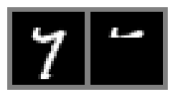

INFO:lightning_fabric.utilities.seed:Seed set to 1


  0%|          | 0/28 [00:00<?, ?it/s]

Autocompletion samples:


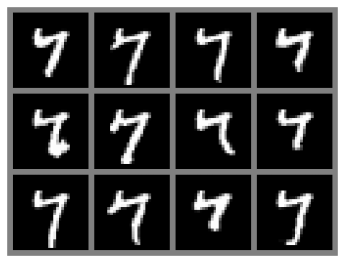

Original image and input image to sampling:


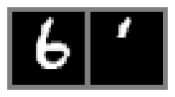

INFO:lightning_fabric.utilities.seed:Seed set to 1


  0%|          | 0/28 [00:00<?, ?it/s]

Autocompletion samples:


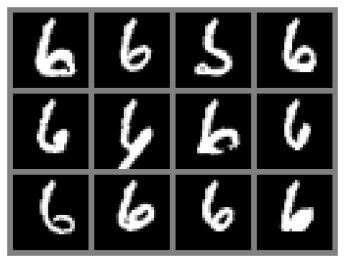

Original image and input image to sampling:


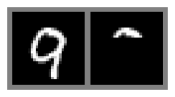

INFO:lightning_fabric.utilities.seed:Seed set to 1


  0%|          | 0/28 [00:00<?, ?it/s]

Autocompletion samples:


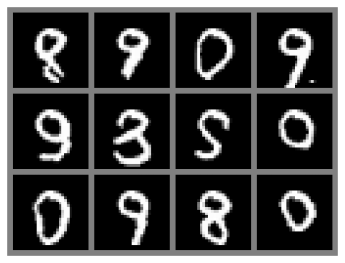

In [ ]:
def autocomplete_image(img):
    # Remove lower half of the image
    img_init = img.clone()
    img_init[:,10:,:] = -1
    print("Original image and input image to sampling:")
    show_imgs([img,img_init])
    # Generate 12 example completions
    img_init = img_init.unsqueeze(dim=0).expand(12,-1,-1,-1).to(device)
    pl.seed_everything(1)
    img_generated = model.sample(img_init.shape, img_init)
    print("Autocompletion samples:")
    show_imgs(img_generated)

for i in range(1,4):
    img = train_set[i][0]
    autocomplete_image(img)

Для первых двух цифр (7 и 6) мы видим, что **все 12 сгенерированных вариантов сохраняют форму, напоминающую оригинальную цифру**.

* Однако **есть различия в стиле написания 7** и **некоторые деформированные шестерки** в выборке.

При автодополнении 9 ниже мы видим, что **модель может “подстроить” под неё несколько разных цифр**.

* В полученных примерах встречаются **0, 3, 8 и 9**.

Это показывает, что **несмотря на отсутствие латентного пространства**, мы всё равно можем **получать разнообразные сэмплы из авторегрессионной модели**.

### Визуализация предсказательного распределения (softmax)

Авторегрессионные модели используют **softmax по 256 значениям** для предсказания следующего пикселя.

* Это даёт модели **большую гибкость**, так как **вероятности каждого значения пикселя могут обучаться независимо**, если это необходимо.
* Однако на самом деле **значения не независимы**: например, 32 и 33 ближе друг к другу, чем 32 и 255.

В следующем шаге мы **визуализируем распределение softmax**, которое предсказывает модель, чтобы понять, **как она усвоила взаимосвязь между близкими значениями пикселей**.

Для этого мы сначала **прогоняем модель на батче изображений** и **сохраняем выходные softmax распределения**.


In [ ]:
det_loader = data.DataLoader(train_set, batch_size=128, shuffle=False, drop_last=False)
imgs,_ = next(iter(det_loader))
imgs = imgs.to(device)
with torch.no_grad():
    out = model(imgs)
    out = F.softmax(out, dim=1)
    mean_out = out.mean(dim=[0,2,3,4]).cpu().numpy()
    out = out.cpu().numpy()

Давайте теперь **визуализируем распределение значений пикселей во всём датасете**.

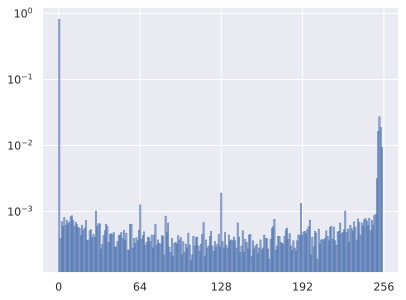

In [ ]:
sns.set()
plot_args = {"color": to_rgb("C0")+(0.5,), "edgecolor": "C0", "linewidth": 0.5, "width": 1.0}
plt.hist(imgs.view(-1).cpu().numpy(), bins=256, density=True, **plot_args)
plt.yscale("log")
plt.xticks([0,64,128,192,256])
plt.show()
plt.close()

Как и следовало ожидать, **значение пикселя 0 (чёрный)** является доминирующим, за ним следует группа значений **от 250 до 255**.

* Обратите внимание, что **ось y отображается в логарифмическом масштабе** из-за сильного дисбаланса в датасете.
* Интересно, что **значения 64, 128 и 191** также выделяются, что, вероятно, связано с **квантованием**, использованным при создании датасета.

Для RGB-изображений также можно было бы увидеть **два пика около 0 и 255**, но значения между ними встречались бы **гораздо чаще, чем в MNIST** (см. Рисунок 1 в PixelCNN++ для CIFAR10).

---

Далее мы можем **визуализировать распределение, которое предсказывает наша модель (в среднем)**.

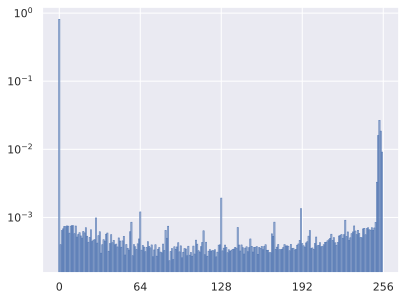

In [ ]:
plt.bar(np.arange(mean_out.shape[0]), mean_out, **plot_args)
plt.yscale("log")
plt.xticks([0,64,128,192,256])
plt.show()
plt.close()

Это распределение **очень близко к реальному распределению датасета**, что в целом является **хорошим признаком**, хотя гистограмма немного **сглаженнее**, чем выше.

---

Наконец, чтобы **лучше понять, какие зависимости между значениями пикселей модель выучила**, можно **визуализировать распределение для отдельных предсказаний пикселей**.

* Для этого мы **выбираем 4 случайных изображения и пикселя** и визуализируем их распределение ниже.

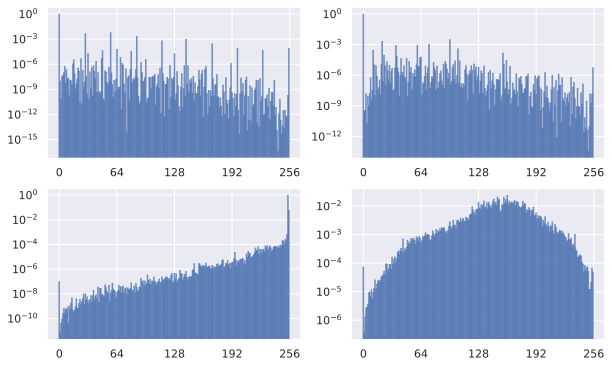

In [ ]:
fig, ax = plt.subplots(2,2, figsize=(10,6))
for i in range(4):
    ax_sub = ax[i//2][i%2]
    ax_sub.bar(np.arange(out.shape[1], dtype=np.int32), out[i+4,:,0,14,14], **plot_args)
    ax_sub.set_yscale("log")
    ax_sub.set_xticks([0,64,128,192,256])
plt.show()
plt.close()

В целом мы видим **очень разнообразный набор распределений**, с обычным пиком около 0 и близко к 1.

Однако распределения в первой строке показывают **потенциально нежелательное поведение**:

* Например, значение **242 имеет вероятность в 1000 раз ниже, чем 243**, хотя они очень близки и часто **неразличимы визуально**.
* Это показывает, что модель **возможно плохо обобщила зависимости между близкими значениями пикселей**.

---

**Лучшее решение этой проблемы** — использовать **смеси дискретных логистических распределений (discrete logistics)** вместо softmax.

* **Дискретная логистика** — это, грубо говоря, **дискретизированные, биновые гауссианы**.
* Использование **смеси дискретных логистик** вместо softmax вводит **индуктивное смещение**, заставляя модель **присваивать близким значениям пикселей похожие вероятности**.

Ниже можно **визуализировать пример дискретной логистики**.


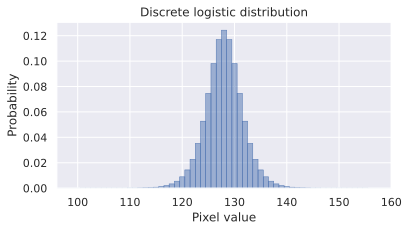

In [ ]:
mu = torch.Tensor([128])
sigma = torch.Tensor([2.0])

def discrete_logistic(x, mu, sigma):
    return torch.sigmoid((x+0.5-mu)/sigma) - torch.sigmoid((x-0.5-mu)/sigma)

x = torch.arange(256)
p = discrete_logistic(x, mu, sigma)

# Visualization
plt.figure(figsize=(6,3))
plt.bar(x.numpy(), p.numpy(), **plot_args)
plt.xlim(96,160)
plt.title("Discrete logistic distribution")
plt.xlabel("Pixel value")
plt.ylabel("Probability")
plt.show()
plt.close()

Вместо softmax модель будет **выводить средние значения и стандартные отклонения** для (K) логистик, используемых в смеси.

* Это одно из **улучшений авторегрессионных моделей**, которое **PixelCNN++** ввёл по сравнению с оригинальным PixelCNN.


### Заключение

В этом ноутбуке мы рассмотрели **авторегрессионное моделирование изображений** и **реализовали архитектуру PixelCNN**.

* С использованием **маскированных свёрток** мы можем построить **свёрточную сеть**, в которой каждый пиксель **влияет только на все свои предшествующие пиксели**.
* Разделение маскированной свёртки на **горизонтальный и вертикальный стек** позволило **устранить известную слепую область** в правом верхнем ряду пикселя.

В экспериментах **авторегрессионные модели превосходят normalizing flows по bits per dimension**, но **намного медленнее в сэмплинге**.

---

**Улучшения**, которые мы здесь не реализовали:

* **Смеси дискретных логистик**
* **Архитектура с даунсемплингом**
* **Диагональный порядок пикселей** (см. PixelSNAIL)

---

В целом, **авторегрессионные модели** — это **сильное семейство генеративных моделей**,
но они **чаще применяются в задачах последовательностей**, из-за **линейного масштабирующегося времени сэмплинга**, в отличие от квадратичного на изображениях.


## Литература
[1] van den Oord, A., et al. "Pixel Recurrent Neural Networks." arXiv preprint arXiv:1601.06759 (2016). [Link](https://arxiv.org/abs/1601.06759)

[2] van den Oord, A., et al. "Conditional Image Generation with PixelCNN Decoders." In Advances in Neural Information Processing Systems 29, pp. 4790–4798 (2016). [Link](http://papers.nips.cc/paper/6527-conditional-image-generation-with-pixelcnn-decoders.pdf)

[3] Salimans, Tim, et al. "PixelCNN++: Improving the PixelCNN with Discretized Logistic Mixture Likelihood and Other Modifications." arXiv preprint arXiv:1701.05517 (2017). [Link](https://arxiv.org/abs/1701.05517)